In [1]:
# Data cleaning and preparation
#In this notebook, I clean and standardize the raw price data collected in Notebook 01. 

#The goal is to ensure:
#- Consistent time series across all assets
#- Minimal missing data issues
#- A clean dataset ready for factor construction and backtesting

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [4]:
# Set project paths and load the data
project_root = Path.cwd().parent
raw_data_path = project_root / "data" / "raw"
price_data = pd.read_csv(raw_data_path / "prices.csv", index_col=0)
price_data.index = pd.to_datetime(price_data.index)
price_data.head()

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304180,69.343712,136.707809,177.699997,59.450500,21.086666,24.637491,197.220001,168.498230,103.156639,...,20.107000,4.928267,91.602791,72.824989,236.562164,188.755341,193.090408,108.111900,28.855202,58.580429
2018-01-03,40.297153,70.428856,137.338745,181.039993,60.209999,21.317266,24.555101,199.789993,170.520233,104.026054,...,20.504999,5.252614,91.362274,72.736626,238.058441,192.217880,195.115997,109.188194,29.106909,59.730930
2018-01-04,40.484329,70.027206,138.964966,183.220001,60.479500,21.324373,24.876455,200.690002,169.196075,105.399368,...,20.563000,5.280303,91.812286,73.250763,239.061829,194.624008,195.962860,109.594177,29.133244,59.813622
2018-01-05,40.945255,71.246239,140.111282,185.339996,61.457001,21.450724,24.991814,201.419998,167.988144,106.802322,...,20.999001,5.325050,92.076118,73.298973,240.654922,197.959351,199.699692,112.218857,29.305923,59.765404
2018-01-08,40.793175,70.104721,141.230972,185.039993,62.343498,21.502064,24.818779,202.740005,168.641357,107.553200,...,21.205000,5.488213,91.548485,73.684608,241.094971,198.282104,196.233536,112.672050,29.739086,60.034081


In [5]:
#In Notebook 1, I extracted the "Close" prices from raw OHLC market data.
#The dataset saved to CSV is already a wide-format matrix where each column represents a single asset's closing price.
#Therefore, in this notebook, no further column selection is required.

In [6]:
# Data validation
close_prices = price_data.copy()
print("Shape of the close price data:", close_prices.shape)
print("Start date:", close_prices.index.min())
print("End date:", close_prices.index.max())
print("Number of assest:", close_prices.shape[1])
print("Duplicate dates:", close_prices.index.duplicated().sum())
print("Duplicate tickers:", close_prices.columns.duplicated().sum())
print("Total missing values", close_prices.isna().sum().sum())

Shape of the close price data: (2074, 31)
Start date: 2018-01-02 00:00:00
End date: 2026-04-02 00:00:00
Number of assest: 31
Duplicate dates: 0
Duplicate tickers: 0
Total missing values 0


In [7]:
# Check data type and sort
close_prices.info()
close_prices.sort_index()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2074 entries, 2018-01-02 to 2026-04-02
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2074 non-null   float64
 1   ABBV    2074 non-null   float64
 2   ACN     2074 non-null   float64
 3   ADBE    2074 non-null   float64
 4   AMZN    2074 non-null   float64
 5   AVGO    2074 non-null   float64
 6   BAC     2074 non-null   float64
 7   BRK-B   2074 non-null   float64
 8   COST    2074 non-null   float64
 9   CRM     2074 non-null   float64
 10  CVX     2074 non-null   float64
 11  GOOGL   2074 non-null   float64
 12  HD      2074 non-null   float64
 13  JPM     2074 non-null   float64
 14  KO      2074 non-null   float64
 15  LLY     2074 non-null   float64
 16  MA      2074 non-null   float64
 17  MCD     2074 non-null   float64
 18  META    2074 non-null   float64
 19  MRK     2074 non-null   float64
 20  MSFT    2074 non-null   float64
 21  NFLX    2074 non-nu

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304180,69.343712,136.707809,177.699997,59.450500,21.086666,24.637491,197.220001,168.498230,103.156639,...,20.107000,4.928267,91.602791,72.824989,236.562164,188.755341,193.090408,108.111900,28.855202,58.580429
2018-01-03,40.297153,70.428856,137.338745,181.039993,60.209999,21.317266,24.555101,199.789993,170.520233,104.026054,...,20.504999,5.252614,91.362274,72.736626,238.058441,192.217880,195.115997,109.188194,29.106909,59.730930
2018-01-04,40.484329,70.027206,138.964966,183.220001,60.479500,21.324373,24.876455,200.690002,169.196075,105.399368,...,20.563000,5.280303,91.812286,73.250763,239.061829,194.624008,195.962860,109.594177,29.133244,59.813622
2018-01-05,40.945255,71.246239,140.111282,185.339996,61.457001,21.450724,24.991814,201.419998,167.988144,106.802322,...,20.999001,5.325050,92.076118,73.298973,240.654922,197.959351,199.699692,112.218857,29.305923,59.765404
2018-01-08,40.793175,70.104721,141.230972,185.039993,62.343498,21.502064,24.818779,202.740005,168.641357,107.553200,...,21.205000,5.488213,91.548485,73.684608,241.094971,198.282104,196.233536,112.672050,29.739086,60.034081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,248.800003,209.399994,192.600006,234.839996,199.339996,300.679993,46.970001,468.489990,983.859985,179.309998,...,93.430000,167.520004,153.039993,142.710007,634.090027,473.359985,259.019989,295.519989,122.889999,170.990005
2026-03-30,246.630005,213.119995,197.550003,241.130005,200.949997,293.410004,47.230000,474.660004,996.580017,185.029999,...,92.970001,165.169998,156.820007,144.720001,631.969971,480.049988,261.790009,299.540009,123.500000,171.470001
2026-03-31,253.789993,217.490005,198.289993,243.080002,208.270004,309.510010,48.750000,479.200012,996.429993,186.669998,...,96.150002,174.399994,155.289993,144.440002,650.340027,491.529999,270.589996,302.239990,124.279999,169.660004


In [8]:
# Check for non-positive values
non_positive_counts = (close_prices<=0).sum().sort_values(ascending=False)
problem_assets = non_positive_counts[non_positive_counts>0]
print(f"Number of non-positive values is: {len(problem_assets)}")
print(problem_assets)

Number of non-positive values is: 0
Series([], dtype: int64)


In [9]:
close_prices.describe()

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
count,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,...,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000
mean,139.175227,119.115493,248.680887,402.947348,142.710980,90.520635,32.359717,311.633312,502.204469,206.368085,...,52.310829,48.649151,131.372643,123.635107,401.651862,443.917874,362.614280,219.899302,52.838359,75.753186
std,69.139777,50.857114,70.667806,121.031315,48.334566,94.539266,8.906321,106.501080,269.319083,56.255464,...,26.883127,58.346150,26.234254,30.002399,131.821811,132.753469,116.312601,66.185782,25.075362,30.124264
min,33.768066,48.014366,120.927460,177.699997,59.450500,14.411802,15.615929,162.130005,159.810226,102.781181,...,16.636999,3.150397,75.162003,57.956528,204.944870,188.755341,176.098083,107.498230,24.413349,23.985264
25%,66.591503,70.711010,178.798954,296.074997,95.043875,25.865692,25.153723,211.800003,274.393860,156.174946,...,33.313750,6.564649,111.057995,103.148573,275.826752,310.742432,249.348263,173.574589,36.252397,51.929193
50%,144.700996,119.977100,261.469788,385.315002,144.803497,48.119892,30.227106,288.110001,461.473862,204.900406,...,43.745501,18.541377,137.597107,129.005852,389.851761,491.362534,354.196411,208.818291,44.841480,68.172199
75%,188.063332,154.367188,303.939468,496.027489,176.270622,124.882893,38.275544,403.435013,715.164322,250.482037,...,62.039001,82.533175,153.813339,146.264870,492.642006,549.721664,471.372253,264.517662,58.213776,103.112190
max,285.922455,240.694290,394.312805,688.369995,254.000000,411.318512,56.928177,539.799988,1070.990479,365.067413,...,133.912994,207.017273,177.249710,173.840240,693.595764,659.204895,603.201233,371.152252,133.615784,171.470001


In [10]:
# Summary stats
close_prices.describe().T.head()
# Daily returns check
daily_returns = close_prices.pct_change()
daily_returns.describe().T[["mean", "std", "min", "max"]].head()

,mean,std,min,max
AAPL,0.001078,0.019290,-0.128647,0.153288
ABBV,0.000676,0.016857,-0.162524,0.137673
ACN,0.000342,0.017631,-0.095881,0.128573
ADBE,0.000410,0.022668,-0.167932,0.177193
AMZN,0.000842,0.021620,-0.140494,0.135359


In [11]:
# Check for extreme return
extreme_moves = (daily_returns.abs() > 0.2).sum().sort_values(ascending=False)
print(extreme_moves[extreme_moves > 0])

META    4
CVX     2
NFLX    2
UNH     1
AVGO    1
NVDA    1
CRM     1
dtype: int64


In [12]:
#Several assets (e.g., META, CVX, NFLX) exhibit daily returns exceeding 20%. 
#These extreme moves may correspond to earnings announcements, corporate actions such as stock splits, or potential data inconsistencies. 
#Further inspection of individual cases is required to distinguish between real market events and data anomalies.

In [13]:
# Inspect META
meta_returns = daily_returns["META"]
meta_extreme = meta_returns[meta_returns.abs() > 0.2]
print(meta_extreme)

Date
2022-02-03   -0.263901
2022-10-27   -0.245571
2023-02-02    0.232824
2024-02-02    0.203177
Name: META, dtype: float64


In [14]:
close_prices.loc[meta_extreme.index, "META"]

Date
2022-02-03    235.908707
2022-10-27     97.177399
2023-02-02    187.300156
2024-02-02    471.291565
Name: META, dtype: float64

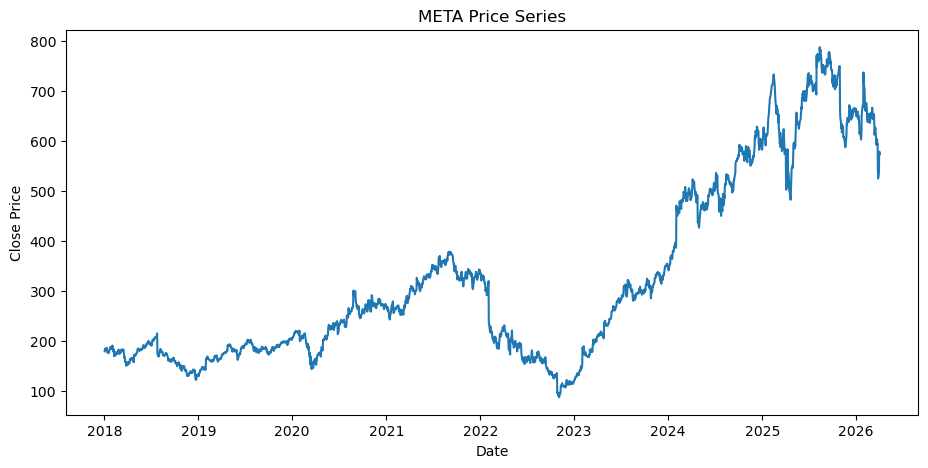

In [15]:
plt.figure(figsize=(11,5))
sns.lineplot(x=close_prices.index, y=close_prices["META"])
plt.title("META Price Series")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [16]:
#META exhibits several extreme daily returns (>20%), which upon inspection correspond to earnings announcements and major corporate developments. 
#These events represent genuine market reactions rather than data errors, so they are retained in the dataset.

In [17]:
# Inspect NFLX
nflx_returns = daily_returns["NFLX"]
nflx_extreme = nflx_returns[nflx_returns.abs() > 0.2]
print(nflx_extreme)

Date
2022-01-21   -0.217905
2022-04-20   -0.351166
Name: NFLX, dtype: float64


In [18]:
close_prices.loc[nflx_extreme.index, "NFLX"]

Date
2022-01-21    39.750000
2022-04-20    22.618999
Name: NFLX, dtype: float64

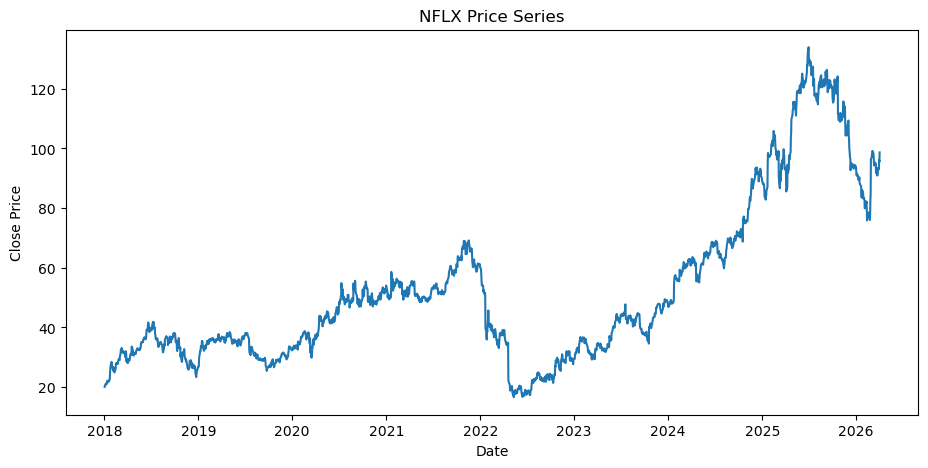

In [19]:
plt.figure(figsize=(11,5))
sns.lineplot(x=close_prices.index, y=close_prices["NFLX"])
plt.title("NFLX Price Series")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [20]:
#Data Validation Conclusion
#The dataset was validated for structural consistency, missing values, and financial plausibility. No non-positive prices or duplicate entries were detected.
#Extreme daily returns (>20%) were identified for several assets, including META and NFLX. Upon inspection, these events correspond to earnings announcements and major corporate developments rather than data errors.
#Therefore, the dataset is considered clean and suitable for downstream return modeling and portfolio analysis.

In [22]:
project_root = Path.cwd().parent
clean_path = project_root / "data" / "processed"
clean_path.mkdir(parents=True, exist_ok=True)
close_prices.to_csv(clean_path / "clean_close_prices.csv")
daily_returns.to_csv(clean_path / "daily_returns.csv")